In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

print(pd.__version__)
print(sns.__version__)

2.3.3
0.13.2


In [2]:
sns.color_palette('Paired')
sns.set_theme(style='whitegrid')
st = sns.axes_style("whitegrid")

# Constants

In [3]:
JDK_NAME = 'jdk-21-ga'

COLD_START_LABEL = 'cold start'
WARM_UP_LABEL = 'warm-up'

DEFAULT_TOOLS = ['Revapi', 'Japicmp', 'RoseauJDT', 'RoseauASM']
TOOL_MARKERS = ['o', 's', 'D', '^', 'v', 'P']
TOOL_PALETTE = {
    'Revapi': '#1f77b4',
    'Japicmp': '#ff7f0e',
    'RoseauJDT': '#2ca02c',
    'RoseauASM': '#d62728',
}
JDK_HIGHLIGHT_COLOR = '#111111'

# Functions

In [4]:
def clean_data(data, libs_info, jdk_name=None):
    if jdk_name:
        library_name_lambda = lambda x: JDK_NAME
        selected_data = data[data['benchmark'].str.contains('OnJdk')]
    else:
        library_name_lambda = lambda x: x['library']
        selected_data = data[data['benchmark'].str.contains('OnTop')]

    cleaned_data = pd.DataFrame(columns=['library', 'method', 'score'])

    cleaned_data['library'] = selected_data.params.apply(library_name_lambda)
    cleaned_data['method'] = (selected_data.benchmark
    .apply(lambda x: x.split('.')[-1])
    .replace({
        'japicmp': 'Japicmp',
        'revapi': 'Revapi',
        'roseauJar': 'RoseauASM',
        'roseauSources': 'RoseauJDT',
        'roseauJdtSources': 'RoseauJDT',
    }))
    cleaned_data['score'] = selected_data.primaryMetric.apply(lambda pm: [x for xs in pm['rawData'] for x in xs])
    cleaned_data = pd.merge(cleaned_data, libs_info, left_on='library', right_on='name', how='left').drop('name', axis=1)
    cleaned_data['apiTotal'] = cleaned_data.apiTypes + cleaned_data.apiMethods + cleaned_data.apiFields

    return cleaned_data.explode('score')


def clean_all_data(data, type):
    data_type_selection = r'\.ToolsPerf' if type == WARM_UP_LABEL else '.ColdStartToolsPerf'
    type_data = data[data['benchmark'].str.contains(data_type_selection)]

    jdk_cleaned_data = clean_data(type_data, libs_downloaded, JDK_NAME)
    libs_cleaned_data = clean_data(type_data, libs_downloaded)

    cleaned_data = pd.concat([jdk_cleaned_data, libs_cleaned_data])
    cleaned_data = cleaned_data.sort_values(['lines', 'method'], ascending=[False, True])
    cleaned_data = cleaned_data.loc[cleaned_data['lines'] >= 100]
    cleaned_data.insert(0, 'type', type)
    cleaned_data["score"] = pd.to_numeric(cleaned_data["score"])

    return cleaned_data.reset_index(drop=True)

In [5]:
def get_tool_order(data, tools_selection=None):
    available = list(pd.Series(data['method'].dropna().unique()))

    if tools_selection is None:
        preferred = DEFAULT_TOOLS
    else:
        preferred = tools_selection

    ordered = [tool for tool in preferred if tool in available]
    return ordered or available


def summarize_benchmark_data(data, tools_selection=None, libs_exclusion=None):
    tool_order = get_tool_order(data, tools_selection)
    summary_data = data.copy()

    if tool_order:
        summary_data = summary_data[summary_data['method'].isin(tool_order)]
    if libs_exclusion:
        summary_data = summary_data[~summary_data['library'].isin(libs_exclusion)]

    summary = (
        summary_data
        .groupby(['library', 'method', 'lines', 'apiTypes', 'apiMethods', 'apiFields', 'apiTotal'], as_index=False)['score']
        .agg(mean='mean', median='median', min='min', max='max', std='std', sample_count='count')
    )
    summary['std'] = summary['std'].fillna(0)
    summary['sample_count'] = summary['sample_count'].astype(int)
    summary['method'] = pd.Categorical(summary['method'], categories=tool_order, ordered=True)

    return summary.sort_values(['lines', 'library', 'method'], ascending=[False, True, True]).reset_index(drop=True)


def build_warm_up_comparison_table(summary, tools_selection=None):
    tool_order = get_tool_order(summary, tools_selection)
    metadata = summary[['library', 'lines', 'apiTypes', 'apiMethods', 'apiFields', 'apiTotal']].drop_duplicates().set_index('library')

    wide = summary.pivot(index='library', columns='method', values=['mean', 'median', 'min', 'max', 'std'])
    wide = wide.reindex(columns=pd.MultiIndex.from_product([['mean', 'median', 'min', 'max', 'std'], tool_order]))
    wide = wide.swaplevel(0, 1, axis=1)
    wide = wide.sort_index(axis=1, level=0, sort_remaining=False)
    wide.columns = [f'{method}_{stat}' for method, stat in wide.columns]

    return metadata.join(wide).reset_index().sort_values(['lines', 'library'], ascending=[False, True]).reset_index(drop=True)


def display_warm_up_summary_tables(summary, comparison_table):
    display(Markdown('### Warm-up summary statistics by library and tool'))
    display(summary[['library', 'method', 'lines', 'apiTotal', 'mean', 'median', 'min', 'max', 'std', 'sample_count']].round(2))

    display(Markdown('### Warm-up comparison table by library'))
    display(comparison_table.round(2))


def prepare_median_plot_data(data, entity, tools_selection=None, libs_exclusion=None):
    tool_order = get_tool_order(data, tools_selection)
    plot_data = data.copy()

    if tool_order:
        plot_data = plot_data[plot_data['method'].isin(tool_order)]
    if libs_exclusion:
        plot_data = plot_data[~plot_data['library'].isin(libs_exclusion)]

    grouped = (
        plot_data
        .groupby(['library', 'method', entity], as_index=False)['score']
        .median()
    )
    grouped['method'] = pd.Categorical(grouped['method'], categories=tool_order, ordered=True)

    return grouped.sort_values(['method', entity, 'library']).reset_index(drop=True)


def plot_impact_of_lib_entity_on_perf(data, entity, label, tools_selection=None, libs_exclusion=None):
    plot_data = prepare_median_plot_data(data, entity, tools_selection, libs_exclusion)

    if plot_data.empty:
        print(f'No data available for {label}.')
        return

    methods = get_tool_order(plot_data, tools_selection)
    fig, ax = plt.subplots(figsize=(18, 7))

    for index, method in enumerate(methods):
        method_data = plot_data[plot_data['method'] == method].sort_values(entity)
        color = TOOL_PALETTE.get(method)
        sns.regplot(
            data=method_data,
            x=entity,
            y='score',
            ax=ax,
            marker=TOOL_MARKERS[index % len(TOOL_MARKERS)],
            color=color,
            truncate=False,
            scatter_kws={'s': 60, 'alpha': 0.75, 'edgecolor': 'white'},
            line_kws={'linewidth': 2.2},
            label=method,
        )

    ax.set_title('Warm-up performance vs library size', fontsize=14, pad=12)
    ax.set_xlabel(f'Library {entity} count')
    ax.set_ylabel('Median execution time (ms)')
    ax.grid(axis='y', color='#d7d7d7', linewidth=0.7)
    ax.legend(title='Tools', frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1.0))
    sns.despine(ax=ax)
    fig.tight_layout()
    fig.savefig(f'impact_of_lib_{entity}_on_perf_{label}.pdf', bbox_inches='tight')
    plt.show()

# Data Extraction

In [6]:
bench_data = pd.read_json('jmh-result.json')
libs_downloaded = pd.read_json('libs_stats.json')

# With Warmup

## Warm-up summary tables

### Warm-up summary statistics by library and tool

,library,method,lines,apiTotal,mean,median,min,max,std,sample_count
0,jdk-21-ga,Revapi,4031099.0,103775.0,52016.06,51656.73,44128.39,62350.40,4992.48,50
1,jdk-21-ga,Japicmp,4031099.0,103775.0,3022.73,2904.13,2841.38,3369.84,185.10,50
2,jdk-21-ga,RoseauASM,4031099.0,103775.0,512.30,511.23,496.24,529.03,8.78,50
3,h2-2.3.232,Revapi,226900.0,10636.0,880.46,879.00,851.64,926.76,13.90,50
4,h2-2.3.232,Japicmp,226900.0,10636.0,164.04,156.63,151.99,204.16,15.96,50
...,...,...,...,...,...,...,...,...,...,...
230,javax.inject-1,RoseauASM,607.0,8.0,3.98,3.75,2.80,7.96,0.96,50
231,maven-plugin-annotations-3.15.1,Revapi,531.0,77.0,96.42,95.73,90.17,107.46,4.07,50
232,maven-plugin-annotations-3.15.1,Japicmp,531.0,77.0,3.17,3.19,2.12,4.20,0.60,50
233,maven-plugin-annotations-3.15.1,RoseauJDT,531.0,77.0,13.31,13.01,9.42,20.24,2.27,50


### Warm-up comparison table by library

,library,lines,apiTypes,apiMethods,apiFields,apiTotal,Japicmp_mean,Japicmp_median,Japicmp_min,Japicmp_max,...,RoseauASM_mean,RoseauASM_median,RoseauASM_min,RoseauASM_max,RoseauASM_std,RoseauJDT_mean,RoseauJDT_median,RoseauJDT_min,RoseauJDT_max,RoseauJDT_std
0,jdk-21-ga,4031099.0,12976.0,66894.0,23905.0,103775.0,3022.73,2904.13,2841.38,3369.84,...,512.30,511.23,496.24,529.03,8.78,NaN,NaN,NaN,NaN,NaN
1,h2-2.3.232,226900.0,781.0,8045.0,1810.0,10636.0,164.04,156.63,151.99,204.16,...,53.94,53.33,47.49,66.84,3.65,553.58,550.26,527.73,580.91,11.52
2,guava-33.4.0-jre,181958.0,440.0,4224.0,417.0,5081.0,480.30,490.70,418.82,521.30,...,39.96,39.64,35.80,46.83,2.95,715.97,711.77,690.49,805.92,22.97
3,assertj-core-3.27.3,160609.0,783.0,6928.0,271.0,7982.0,150.38,144.30,137.44,174.78,...,54.13,53.77,47.14,65.13,3.44,553.54,553.01,522.97,607.29,20.93
4,protobuf-java-4.29.3,140296.0,378.0,7383.0,668.0,8429.0,164.91,159.57,155.04,180.93,...,63.04,63.06,58.81,70.75,2.91,412.17,410.55,387.22,449.87,11.75
5,jackson-databind-2.18.2,133660.0,604.0,6420.0,1217.0,8241.0,133.13,130.09,125.73,157.57,...,60.56,59.85,53.39,71.32,3.87,410.50,407.53,386.18,442.25,12.86
6,spring-core-6.2.3,131980.0,650.0,4080.0,687.0,5417.0,130.75,127.73,124.97,152.80,...,34.90,34.10,28.91,53.28,4.61,420.26,415.81,399.83,475.07,15.61
7,spring-web-6.2.3,122691.0,655.0,3926.0,399.0,4980.0,117.74,114.15,110.62,136.53,...,33.25,32.59,29.35,39.11,2.81,463.96,458.70,432.73,495.34,16.12
8,log4j-core-2.24.3,113123.0,795.0,4224.0,574.0,5593.0,149.90,145.21,141.22,177.18,...,38.71,38.99,34.10,46.67,2.97,386.46,384.40,373.60,418.28,9.76
9,commons-lang3-3.17.0,97613.0,260.0,3266.0,569.0,4095.0,49.13,48.05,43.68,58.47,...,16.87,15.87,13.29,41.68,4.38,253.58,250.91,230.52,301.83,16.48


## Warm-up visualizations

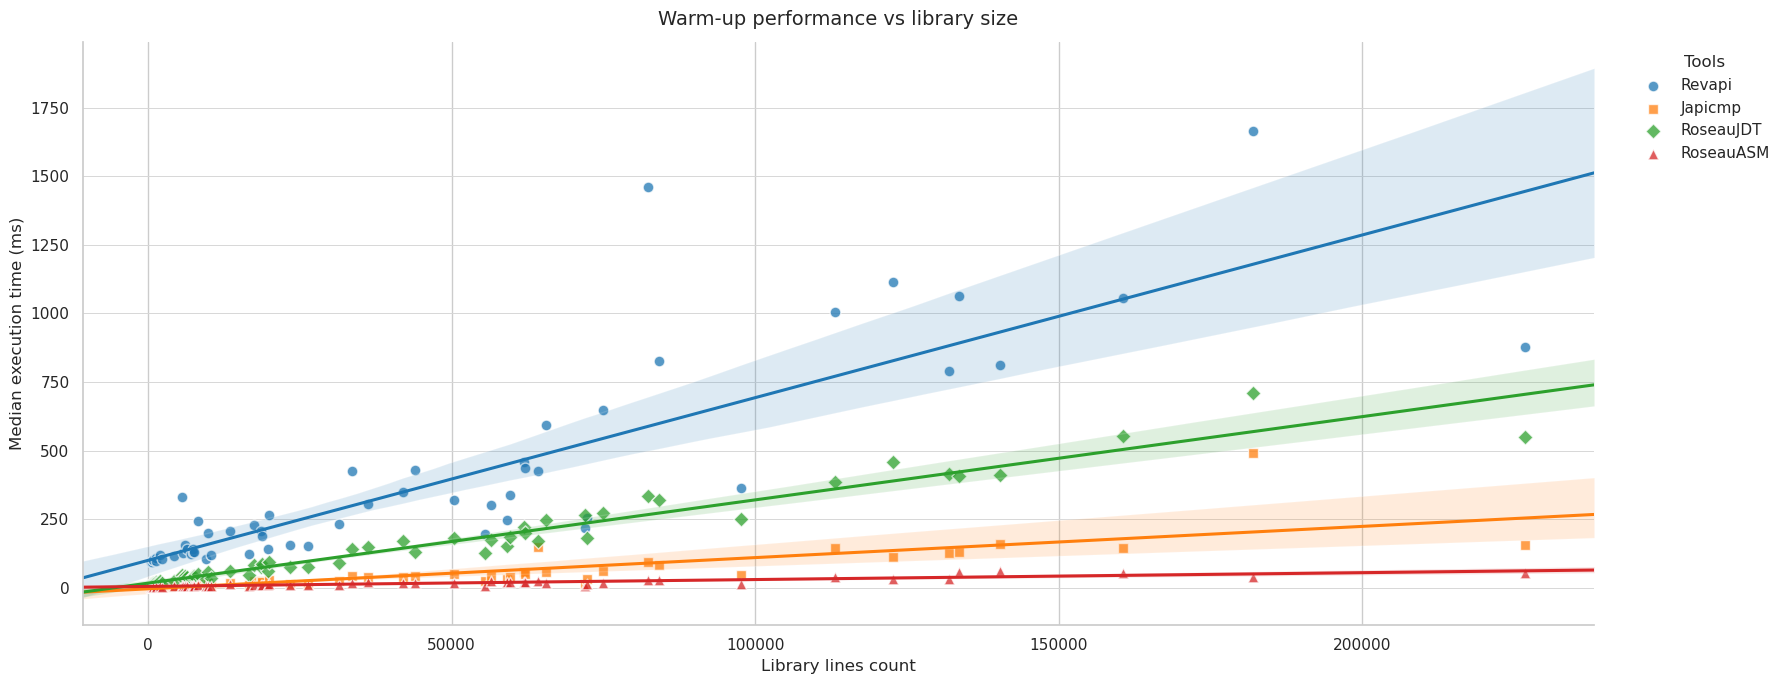

In [7]:
warm_up_cleaned_data = clean_all_data(bench_data, WARM_UP_LABEL)
warm_up_summary_long = summarize_benchmark_data(warm_up_cleaned_data, tools_selection=DEFAULT_TOOLS)
warm_up_summary_wide = build_warm_up_comparison_table(warm_up_summary_long, tools_selection=DEFAULT_TOOLS)

display(Markdown('## Warm-up summary tables'))
display_warm_up_summary_tables(warm_up_summary_long, warm_up_summary_wide)

display(Markdown('## Warm-up visualizations'))
plot_impact_of_lib_entity_on_perf(warm_up_cleaned_data, 'lines', WARM_UP_LABEL, tools_selection=DEFAULT_TOOLS, libs_exclusion=[JDK_NAME])

# Cold Start

Disabled for the current `jmh-result.json`, which only contains warm-up benchmark data.

In [8]:
# The updated jmh-result.json only contains warm-up benchmark runs.
# Cold-start analyses are intentionally disabled for this dataset.
cold_start_cleaned_data = pd.DataFrame()
print('Cold-start analyses disabled: jmh-result.json does not contain ColdStartToolsPerf benchmarks.')

Cold-start analyses disabled: jmh-result.json does not contain ColdStartToolsPerf benchmarks.


# Comparison between Warm-up and Cold Start

Disabled automatically when cold-start benchmark data is not available.

In [9]:
if cold_start_cleaned_data.empty:
    print('Comparison disabled: cold-start data is not available in jmh-result.json.')
else:
    full_data_cleaned = pd.concat([cold_start_cleaned_data, warm_up_cleaned_data])
    full_data_cleaned.head()

Comparison disabled: cold-start data is not available in jmh-result.json.


In [10]:
if cold_start_cleaned_data.empty:
    print('Comparison plot disabled: cold-start data is not available in jmh-result.json.')
else:
    plt.figure(figsize=(5, 4))
    sns.barplot(x='score', y='method', hue='type', estimator='median', data=full_data_cleaned)
    plt.title('Comparison between cold start and warm-up for each tools')
    plt.xlabel('Time in ms')
    plt.ylabel('Tools')
    plt.savefig('comparison_between_cold_start_and_warm_up.pdf', bbox_inches='tight')
    plt.show()

Comparison plot disabled: cold-start data is not available in jmh-result.json.
